In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import keras.datasets.imdb as imdb
from keras import layers, models, preprocessing
from keras.preprocessing.sequence import pad_sequences
from keras.layers import TextVectorization
from keras.models import Sequential
from keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout, Activation
from transformers import pipeline, AutoTokenizer



In [49]:
#Task 1: Utilise Libraries/Dataset

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)
print(train_data.shape)
print(train_labels.shape)
print(test_data.shape)
print(test_labels.shape)

# Retrieve the word index mapping words to their integer IDs
word_index = imdb.get_word_index()
# Create a reverse word index
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Define a function to decode an integer sequence into a readable review
def decode_review(text):
    # Map integer IDs to words, handling the offset and unknown words
    decoded = " ".join([reverse_word_index.get(i - 3, "?") for i in text])
    return decoded

train_reviews = [decode_review(review) for review in train_data]
test_reviews = [decode_review(review) for review in test_data]

# Create DataFrames
train_df = pd.DataFrame({'review': train_reviews, 'sentiment': train_labels})
test_df = pd.DataFrame({'review': test_reviews, 'sentiment': test_labels})

# Display the first few rows of the training DataFrame
print("Training Data Head:")
print(train_df.head())
print(train_df.size)

print("\nTesting Data Head:")
print(test_df.head())
print(test_df.size)

(25000,)
(25000,)
(25000,)
(25000,)
Training Data Head:
                                              review  sentiment
0  ? this film was just brilliant casting locatio...          1
1  ? big hair big boobs bad music and a giant saf...          0
2  ? this has to be one of the worst films of the...          0
3  ? the ? ? at storytelling the traditional sort...          1
4  ? worst mistake of my life br br i picked this...          0
50000

Testing Data Head:
                                              review  sentiment
0  ? please give this one a miss br br ? ? and th...          0
1  ? this film requires a lot of patience because...          1
2  ? many animation buffs consider ? ? the great ...          1
3  ? i generally love this type of movie however ...          0
4  ? like some other people wrote i'm a die hard ...          1
50000


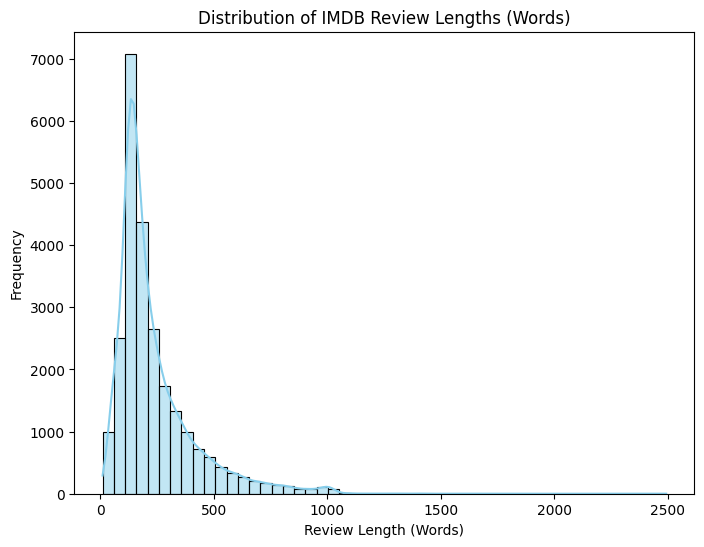

/tmp/ipython-input-3401416365.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette='viridis')


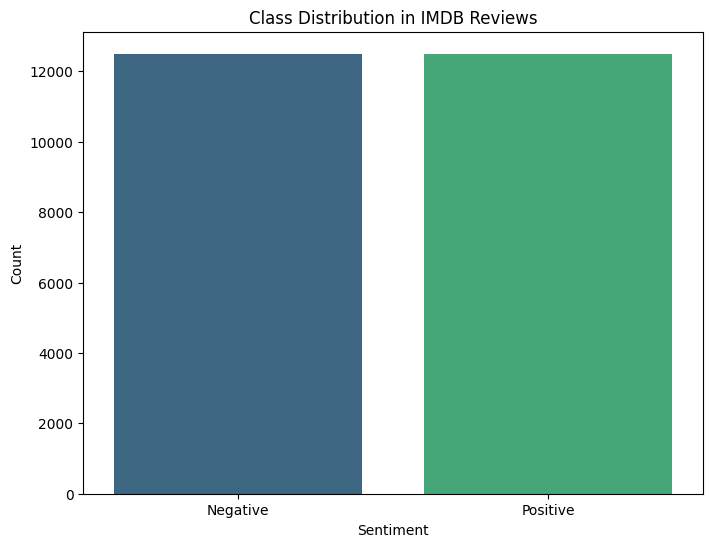

In [51]:
#Task 2: Data Processing and Exploration

def performEDA(df):
  df['review_length'] = df['review'].apply(lambda x: len(x.split()))
  # 1. Plot the distribution of review lengths using a histogram
  plt.figure(figsize=(8, 6))
  sns.histplot(df['review_length'], bins=50, kde=True, color='skyblue')
  plt.title('Distribution of IMDB Review Lengths (Words)')
  plt.xlabel('Review Length (Words)')
  plt.ylabel('Frequency')
  plt.show()
  df.drop('review_length', axis=1, inplace=True)

  # 2. Plot the class distribution
  plt.figure(figsize=(8, 6))
  sns.countplot(data=df, x='sentiment', palette='viridis')
  plt.title('Class Distribution in IMDB Reviews')
  plt.xlabel('Sentiment')
  plt.ylabel('Count')
  plt.xticks(ticks=[0, 1], labels=['Negative', 'Positive'])
  plt.show()

#Generate two EDA visualisations (e.g., review length distribution, class distribution)
performEDA(train_df)


In [52]:

def analyseData(df):
  print("\nMissing Values in Data:")
  print(df.isnull().sum())

#Check for missing values and data quality
analyseData(train_df)

#Convert text into appropriate format using Keras Tokenizer (e.g., maxlen=256)
#Create training and testing splits


Missing Values in Data:
review       0
sentiment    0
dtype: int64


In [ ]:
#Run this code block when we have raw imdb data in excel sheet and loaded to dataframe
import re
import nltk
import torch
#nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import tensorflow as tf
#from keras.preprocessing.text import Tokenizer #Deprecated
from keras.preprocessing.sequence import pad_sequences

# Initialize stemmer and set of stopwords
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def process(review):
  review = re.sub(r'<[^<>]+>', ' ', review) # 1. Remove html and carat tags
  review = re.sub(r'[^a-zA-Z0-9\s]', '', review) # 2. Remove special characters and punctuation, keep only letters, numbers, and spaces
  review = review.lower() # 3. Convert to lowercase
  words = review.split() # 4. Tokenize the review into words
  meaningful_words = [ps.stem(w) for w in words if w not in stop_words] # 5. Remove stopwords and apply stemming
  review = ' '.join(meaningful_words) # 6. Rejoin words into a single string

#def tokenize(df):
  #tokenizer = Tokenizer(num_words=10000)
  #tokenizer.fit_on_texts(df['review'])
  #return tokenizer

#Normalise and tokenise text, pad sequences to a consistent length
#train_df['review'] = train_df['review'].apply(lambda x: process(x))
#test_df['review'] = test_df['review'].apply(lambda x: process(x))
#tokenizer = tokenize(train_df)
#train_rev_tokens = tokenizer.texts_to_sequences(train_df['review'])
#test_rev_tokens = tokenizer.texts_to_sequences(test_df['review'])
#maxlen = 256 # Max length of reviews
#train_df= pad_sequences(train_rev_tokens, maxlen=maxlen, padding='post')
#test_df = pad_sequences(test_rev_tokens, maxlen=maxlen, padding='post')

#Latest supported
#standardize param does normalization, output_sequence_length does padding
max_features = 10000 # Top 10k words
vectorize_layer = TextVectorization(max_tokens=max_features, standardize='lower_and_strip_punctuation', output_mode='int', output_sequence_length=256)
# Create a dataset of only text (no labels)
train_text = train_df['review']
print(train_text.shape)
print(train_text)
vectorize_layer.adapt(train_text)
train_vectors = vectorize_layer(train_df['review'].values)
test_vectors = vectorize_layer(test_df['review'].values)

print(train_df.shape)
print(test_df.shape)
print(train_vectors[0, :])
print(test_vectors)

(25000,)
0        ? this film was just brilliant casting locatio...
1        ? big hair big boobs bad music and a giant saf...
2        ? this has to be one of the worst films of the...
3        ? the scots excel at storytelling the traditio...
4        ? worst mistake of my life br br i picked this...
                               ...                        
24995    ? this is a racist movie but worthy of study a...
24996    ? bela lugosi plays a doctor who will do anyth...
24997    ? in a far away galaxy is a planet called ceta...
24998    ? six degrees had me hooked i looked forward t...
24999    ? as a big fan of the original film it's hard ...
Name: review, Length: 25000, dtype: object
(25000, 2)
(25000, 2)
tf.Tensor(
[[  12   20   14 ...    0    0    0]
 [ 192 1154  192 ...    0    0    0]
 [  12   46    6 ...    0    0    0]
 ...
 [   9    4  227 ...    0    0    0]
 [1439 6965   68 ...    0    0    0]
 [  15    4  192 ...    0    0    0]], shape=(25000, 256), dtype=int64)
tf.T

In [53]:
#As the data is loaded from Keras datasets the data is already preprocessed and tokenized. So applying only padding on direct train and test dataset.
maxlen = 256 # Max length of reviews
train_data = pad_sequences(train_data, maxlen=maxlen, padding='post')
test_data = pad_sequences(test_data, maxlen=maxlen, padding='post')

In [54]:
#Task 3: Construct a basic Transformer model
modell = Sequential()
modell.add(layers.Embedding(10001, 16))
modell.add(layers.Dropout(0.3))
modell.add(layers.GlobalAveragePooling1D())
modell.add(layers.Dense(128))
modell.add(layers.Activation("relu"))
modell.add(layers.Dropout(0.5))
modell.add(layers.Dense(1))
modell.add(layers.Activation("sigmoid"))

modell.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["acc"])
modell.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
#Task 4: Train the basic model
history = modell.fit(train_data, train_labels,
                    epochs=5,
                    batch_size=64,
                  )

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - acc: 0.6127 - loss: 0.6568
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.8619 - loss: 0.3366
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - acc: 0.8964 - loss: 0.2605
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - acc: 0.9120 - loss: 0.2252
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.9197 - loss: 0.2072


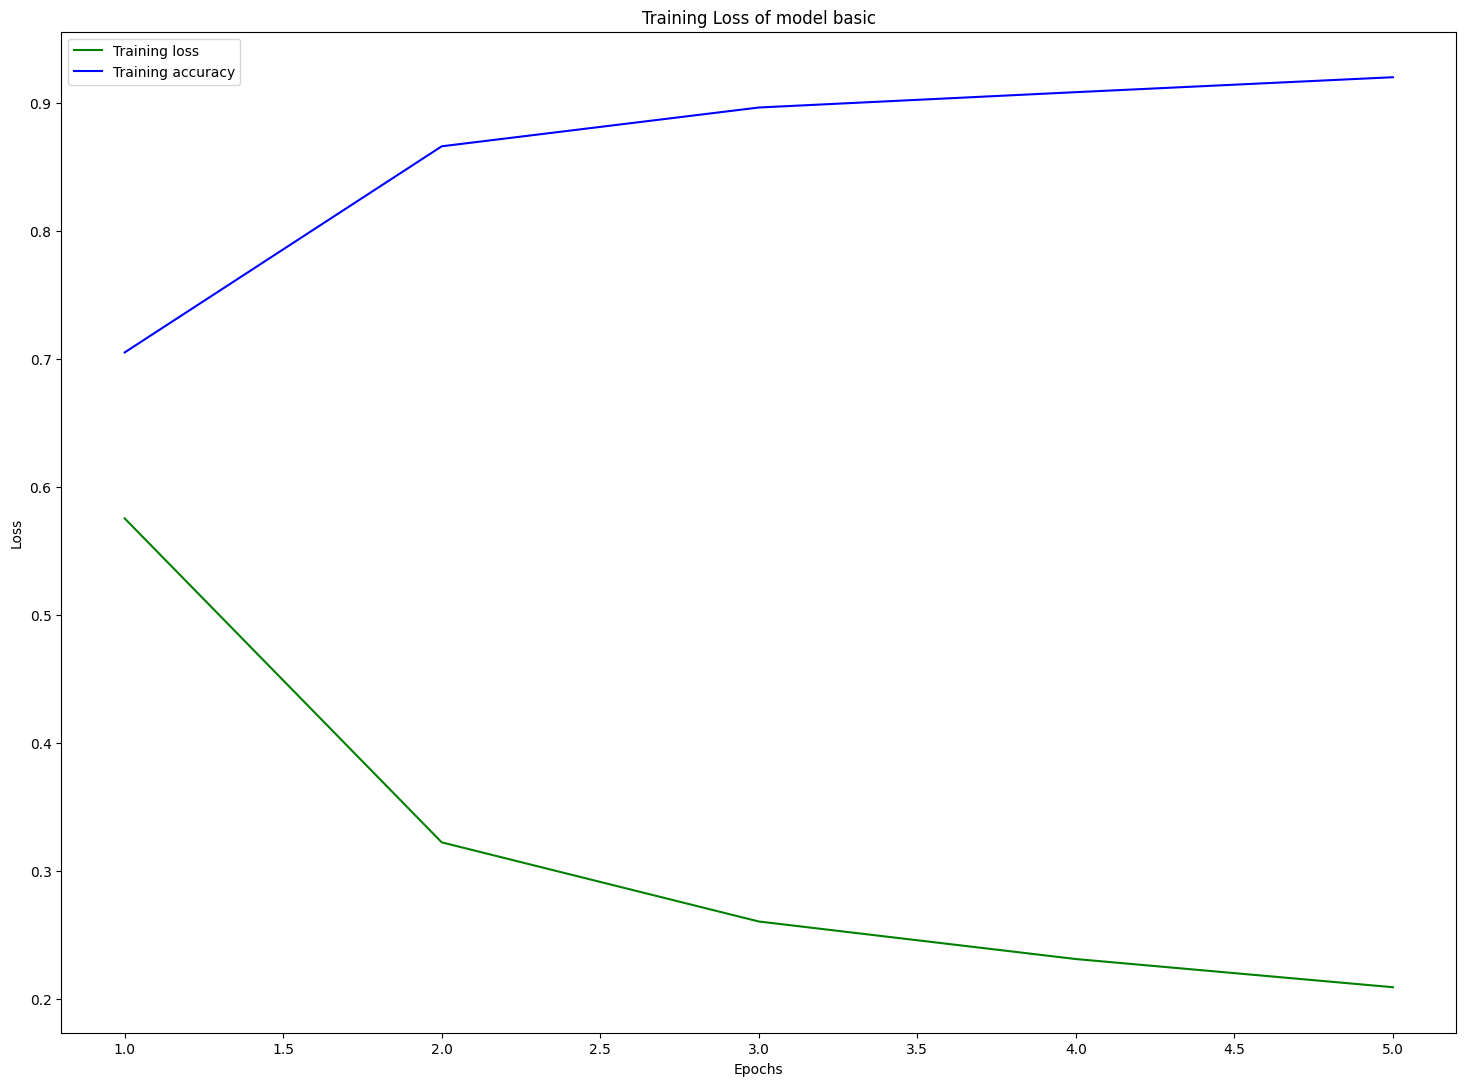

In [59]:
#Task 5: Display model architecture and training progress
def plotTrainingProcess(history, name):
  train_loss = history.history['loss']
  train_accuracy = history.history['acc']
  epochs = range(1, len(train_loss) + 1)

  # Plot the training loss and accuracy
  plt.figure(figsize=(18, 13))
  plt.plot(epochs, train_loss, 'g', label='Training loss')
  plt.plot(epochs, train_accuracy, 'b', label='Training accuracy')
  plt.title(f'Training Loss of model {name}')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()


plotTrainingProcess(history, "basic")

In [108]:
#Task 6: Construct an advanced transformer model
import keras
from keras.layers import Layer
import tensorflow as tf

#Custom positional embedding
class PositionalEmbedding(Layer):
    def __init__(self, sequence_len, vocab_size, embed_dim):
        super(PositionalEmbedding, self).__init__()
        self.word_embeddings = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )
        self.pos_embeddings = Embedding(
            input_dim=sequence_len, # Max sequence length
            output_dim=embed_dim
        )
        self.sequence_len = sequence_len
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

    def build(self, input_shape):
        # Create a trainable weight variable for this layer.
        # Fix for TypeError: Layer.add_weight() got multiple values for argument 'shape'
        # 'shape' should be passed as a positional argument.
        # input_shape will be (batch_size, sequence_length)
        feature_size = input_shape[1] # This is the sequence_length (maxlen)
        self.kernel = self.add_weight(
            (self.sequence_len, feature_size), # Pass shape as a positional argument
            initializer="random_normal",
            trainable=True,
            name="posembed"
        )

    def compute_output_shape(self, input_shape):
        # Fix for incorrect output shape calculation.
        # The output shape of PositionalEmbedding should be (batch_size, sequence_length, embedding_dim)
        return (input_shape[0], input_shape[1], self.embed_dim)

    def call(self, inputs):
        length = tf.shape(inputs)[-1] # Use tf.shape for symbolic tensor shapes
        positions = tf.range(start=0, limit=length, delta=1) # Positions up to sequence length
        embedded_words = self.word_embeddings(inputs) # (batch_size, sequence_length, embed_dim)
        embedded_positions = self.pos_embeddings(positions) # (sequence_length, embed_dim) - will be broadcasted

        return embedded_words + embedded_positions

max_features = 10000
# The 'sequence_len' parameter for PositionalEmbedding should be the maximum length
# of the input sequences (maxlen), not tf.range(max_features).

# Input layer
inputs = keras.Input(shape=(maxlen,))
# Embedding and positional encoding (necessary for attention to understand order)
posembedding_layer = PositionalEmbedding(maxlen, max_features, 16)
x = posembedding_layer(inputs)

# Multi-Head Attention block (self-attention where query, key, value are the same input)
attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=4)(x, x, x)
x = layers.Dropout(0.3)(attn_output)

# Feed Forward block
ffn_output = layers.Dense(32, activation="relu")(x)
#ffn_output = layers.Dense(16)(ffn_output)
x = layers.Dropout(0.5)(ffn_output)

# Output layers
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

# Construct the model
modell2 = keras.Model(inputs=inputs, outputs=outputs)

modell2.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["acc"])
modell2.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 256)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 256, 16)   │     65,536 │ input_layer_21[0… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 16)   │      1,088 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
│                     │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 256, 16)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 256, 32)   │        544 │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_55          │ (None, 256, 32)   │          0 │ dense_49[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ dropout_55[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 32)        │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 1)         │         33 │ dropout_56[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,201 (262.50 KB)

 Trainable params: 67,201 (262.50 KB)

 Non-trainable params: 0 (0.00 B)

In [109]:
#Task 7: Train the advanced model

history2 = modell2.fit(train_data, train_labels,
                    epochs=5,
                    batch_size=64)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:855: UserWarning: Gradients do not exist for variables ['positional_embedding_24/posembed'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 122s 302ms/step - acc: 0.5838 - loss: 0.6464
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 119s 305ms/step - acc: 0.8719 - loss: 0.3126
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 195s 499ms/step - acc: 0.9191 - loss: 0.2213
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 255s 635ms/step - acc: 0.9343 - loss: 0.1837
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 192s 491ms/step - acc: 0.9496 - loss: 0.1512


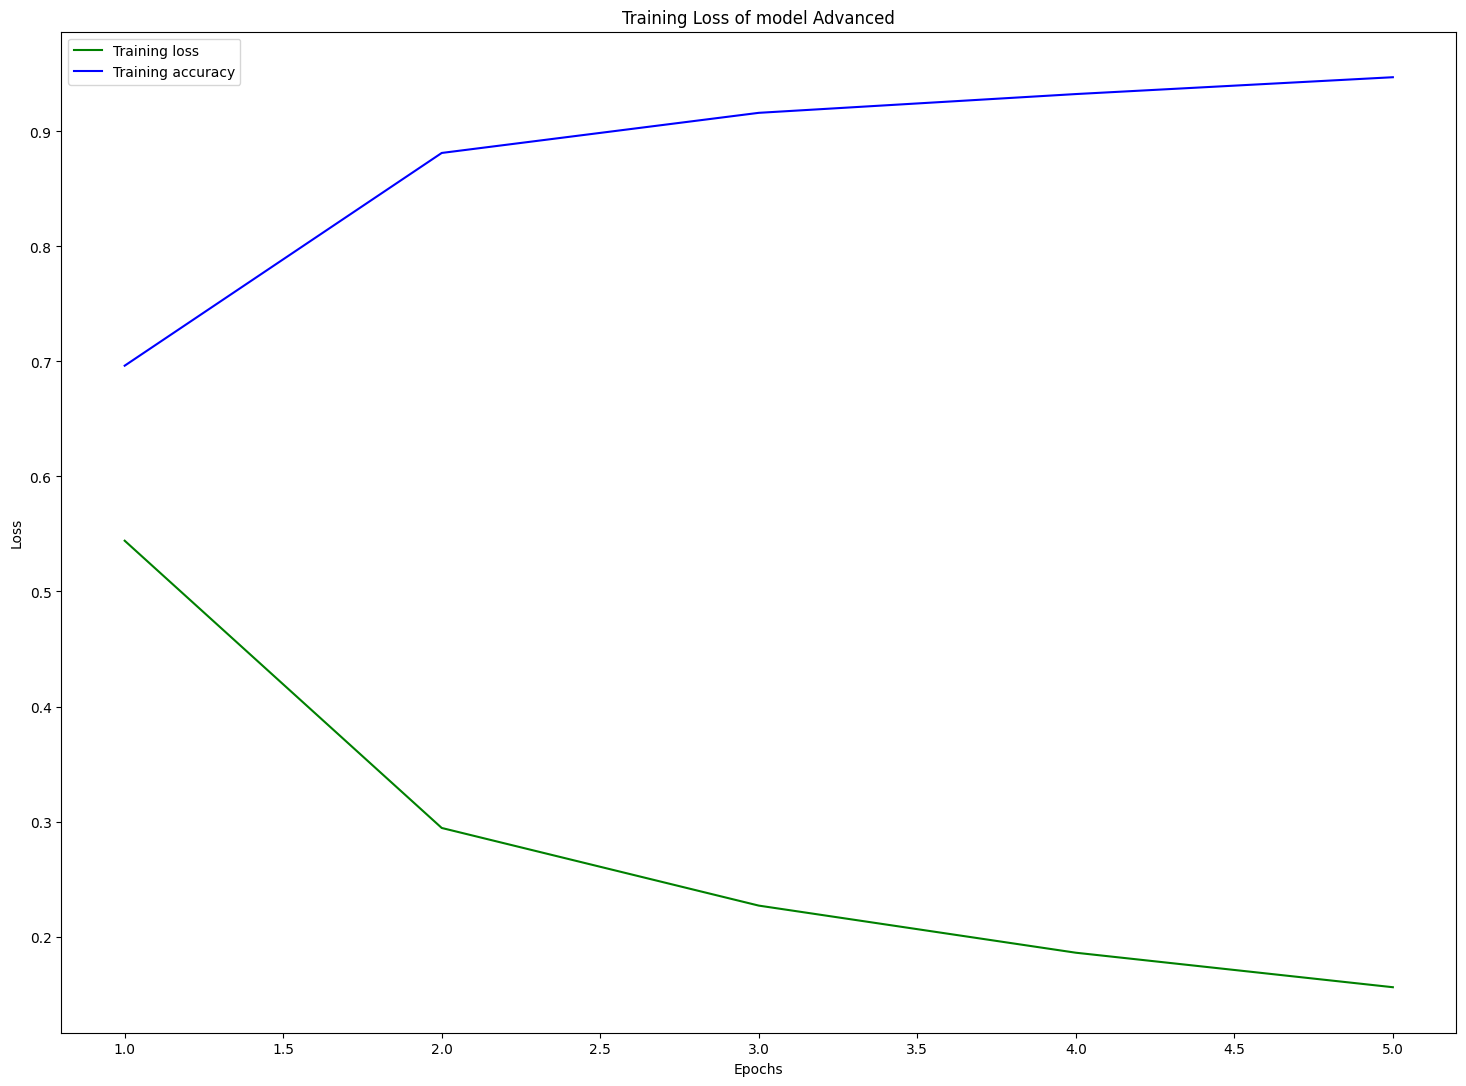

In [110]:
#Task 8: Display model architecture and training progress
plotTrainingProcess(history2, "Advanced")

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - acc: 0.8842 - loss: 0.2865
[0.28992003202438354, 0.8813999891281128]
Accuracy: 88.14
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Accuracy: 0.8814
Precision: 0.8917
Recall: 0.8682
F1 Score: 0.8798
Confusion matrix: [[11182  1318]
 [ 1647 10853]]


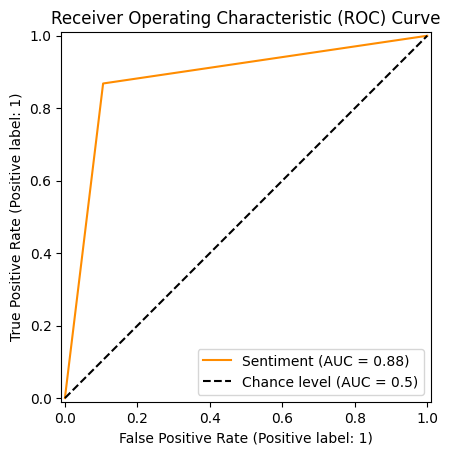

782/782 ━━━━━━━━━━━━━━━━━━━━ 51s 65ms/step - acc: 0.8728 - loss: 0.3373
[0.34441450238227844, 0.8723999857902527]
Accuracy: 87.24
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step
Accuracy: 0.8724
Precision: 0.8859
Recall: 0.8549
F1 Score: 0.8701
Confusion matrix: [[11124  1376]
 [ 1814 10686]]


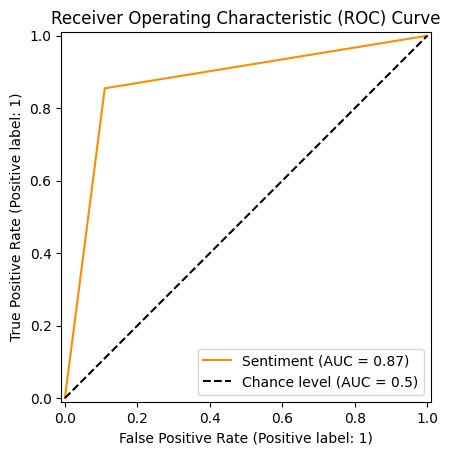

In [111]:
#Task 9: Compare training and validation results for each model using Accuracy, Precision, Recall, F1-score and AUC-ROC:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, RocCurveDisplay

def evaluate(model, test_data, test_labels):
  results = model.evaluate(test_data, test_labels)
  print(results)
  print('Accuracy: %.2f' % (results[1]*100))

  y_pred = model.predict(test_data)
  # round predictions
  rounded = [round(x[0]) for x in y_pred]

  # Calculate individual metrics
  accuracy = accuracy_score(test_labels, rounded)
  precision = precision_score(test_labels, rounded) # Default for binary classification
  recall = recall_score(test_labels, rounded)       # Default for binary classification
  f1 = f1_score(test_labels, rounded)             # Default for binary classification
  cm = confusion_matrix(test_labels, rounded)

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1 Score: {f1:.4f}")
  print(f"Confusion matrix: {cm}")

  RocCurveDisplay.from_predictions(test_labels, rounded,
      name="Sentiment",
      color="darkorange",
      plot_chance_level=True)
  plt.title('Receiver Operating Characteristic (ROC) Curve')
  plt.show()

evaluate(modell, test_data, test_labels)
evaluate(modell2, test_data, test_labels)